<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Aptos;text-align:center;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Actuarial Agents: Responsible AI Agent Teams for Actuarial Risk Prediction</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><b>Author: Bart Custers</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><i>MSc Thesis Artificial Intelligence, School of Computer Science, University of Hull</i></div>

<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:24px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Evaluation: Notebook for deriving output statistics.</b></div>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load the Excel file
file_path = "C:/Users/bart_/Documents/Thesis/results/Workflow_run_stats.xlsx"

df_original = pd.read_excel(file_path, sheet_name="original")
df_test = pd.read_excel(file_path, sheet_name="test")

# Publication style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})

# Inspect columns
print(df_original.columns)
df_original.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'Sparsity_zero',
       'Sparsity_numeric', 'row_change', 'col_change', 'missingness',
       'target_shift', 'avg_psi', 'corr_shift', 'severity_score'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Decision_model_review,Sparsity_zero,Sparsity_numeric,row_change,col_change,missingness,target_shift,avg_psi,corr_shift,severity_score
0,1,20260205_180357,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,20260205_181231,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,20260205_183138,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,20260205_195843,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,20260205_201858,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,0,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Consistency tests on fixed dataset**

### **1. Task Success Rate per LLM**

    LLM_backend  Success_rate
0    Llama 2 7B           0.8
1  Llama 3.1 8B           0.9
2    Qwen2.5 7B           0.8


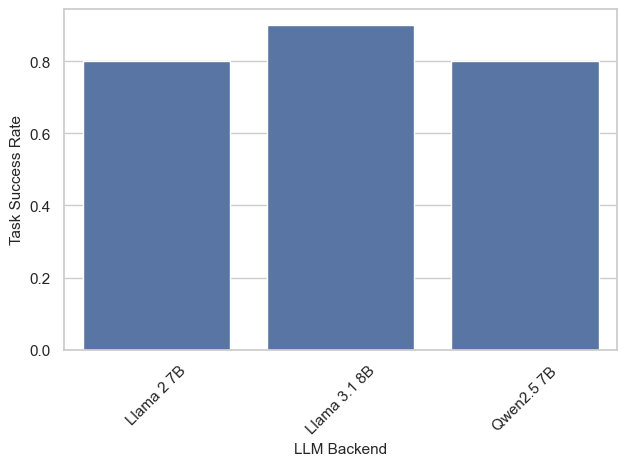

In [16]:
# Ensure Workflow_succes is numeric (0/1)
df_original["Workflow_succes"] = df_original["Workflow_succes"].astype(int)

# Compute success rate per LLM backend
success_rate = (
    df_original.groupby("LLM_backend")["Workflow_succes"]
    .mean()
    .reset_index()
)

success_rate.rename(columns={"Workflow_succes": "Success_rate"}, inplace=True)

print(success_rate)

plt.figure()
sns.barplot(
    data=success_rate,
    x="LLM_backend",
    y="Success_rate"
)

plt.xlabel("LLM Backend")
plt.ylabel("Task Success Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_task_success_rate.png", bbox_inches="tight")
plt.show()

### **2. Workflow outcome per LLM**

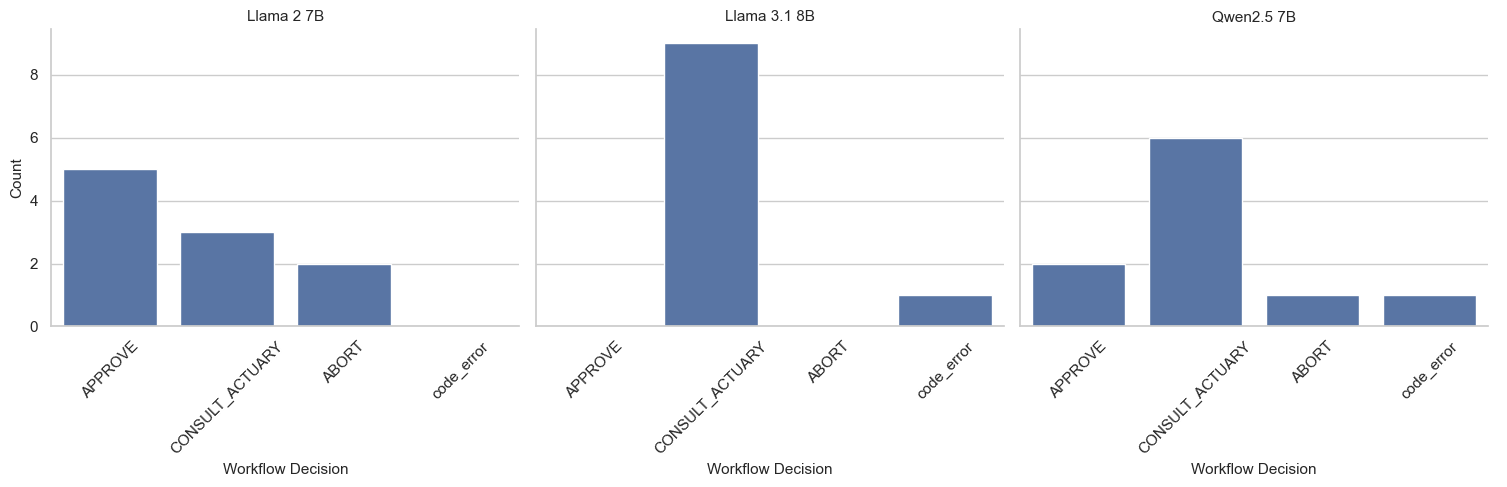

In [17]:
g = sns.catplot(
    data=df_original,
    x="Workflow_decision",
    col="LLM_backend",
    kind="count",
    col_wrap=len(df_original["LLM_backend"].unique()),
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Workflow Decision", "Count")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fig_workflow_decisions.png", bbox_inches="tight")
plt.show()

### **3. Model choice per LLM**

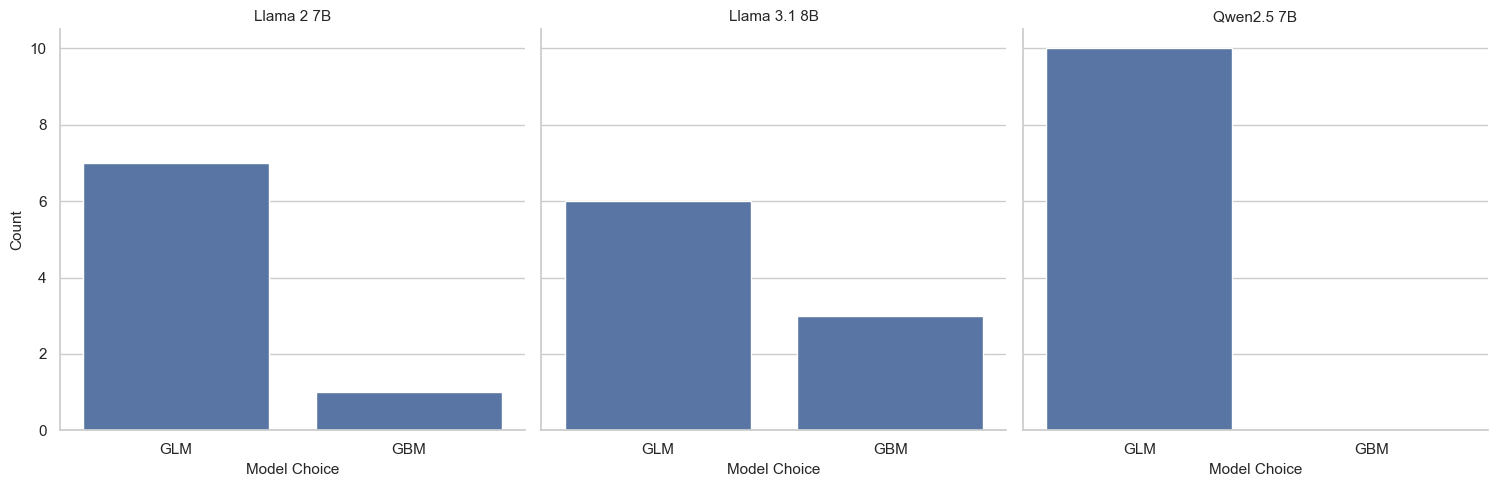

In [18]:
g = sns.catplot(
    data=df_original,
    x="Model_choice",
    col="LLM_backend",
    kind="count",
    col_wrap=len(df_original["LLM_backend"].unique()),
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Model Choice", "Count")
g.set_titles("{col_name}")

#for ax in g.axes.flatten():
 #   ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fig_model_choice.png", bbox_inches="tight")
plt.show()

### **4. Model RMSE per LLM**

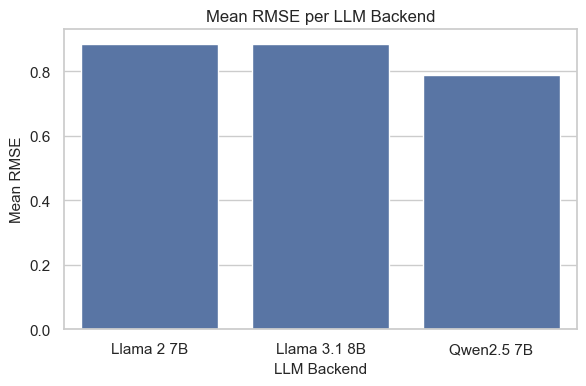

In [19]:
performance_summary = (
    df_original.groupby("LLM_backend")
      .agg({
          "RMSE": "mean",
          "MAE": "mean",
          "Poisson_deviance": "mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=performance_summary,
    x="LLM_backend",
    y="RMSE"
)

plt.title("Mean RMSE per LLM Backend")
plt.xlabel("LLM Backend")
plt.ylabel("Mean RMSE")
plt.tight_layout()
plt.savefig("fig_mean_rmse_per_backend.png", bbox_inches="tight")
plt.show()

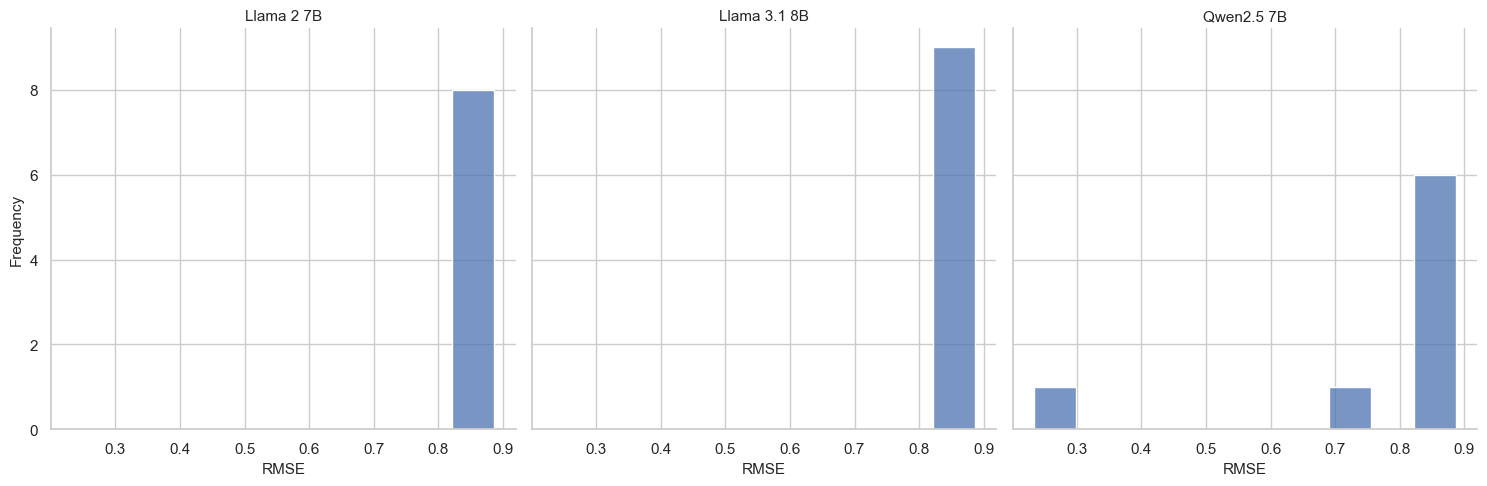

In [20]:
g = sns.displot(
    data=df_original,
    x="RMSE",
    col="LLM_backend",
    col_wrap=len(df_original["LLM_backend"].unique()), 
    bins=10,
    height=5,
    aspect=1,
    facet_kws={"sharey": True}
)

g.set_axis_labels("RMSE", "Frequency")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_rmse_dist_per_backend.png", bbox_inches="tight")
plt.show()

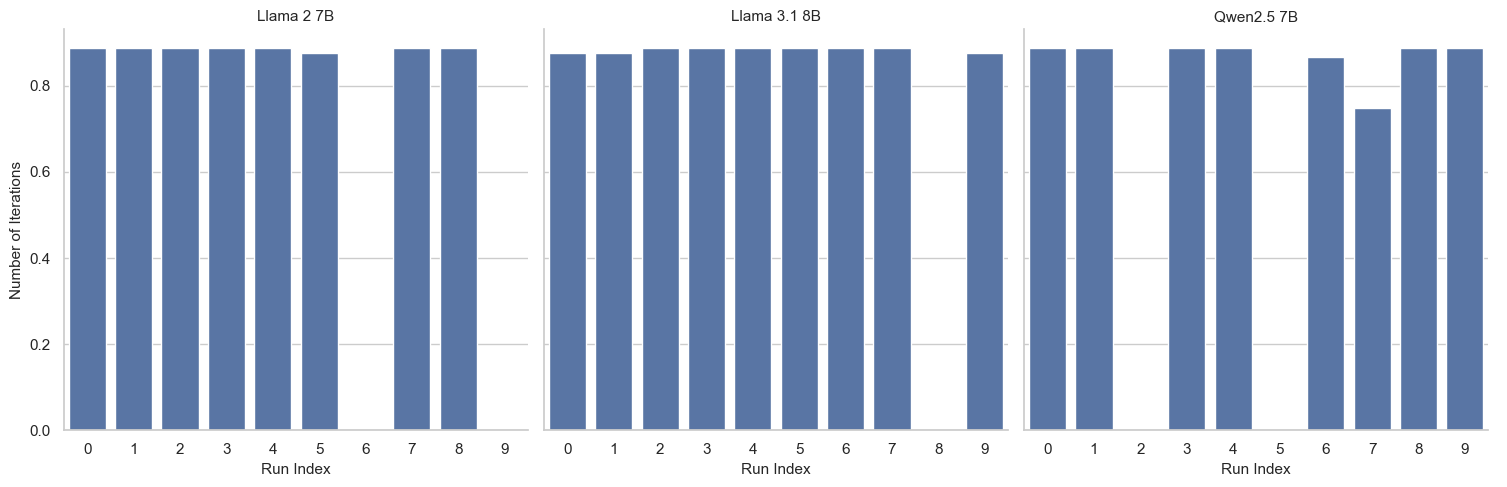

In [48]:
# Ensure numeric
df_original["RMSE"] = pd.to_numeric(
    df_original["RMSE"], errors="coerce"
)

# Create run index per backend (like your reset_index)
df_plot = (
    df_original
    .sort_values(["LLM_backend"])
    .copy()
)

df_plot["Run_Index"] = (
    df_plot.groupby("LLM_backend")
    .cumcount()
)

# Faceted bar plot
g = sns.catplot(
    data=df_plot,
    x="Run_Index",
    y="RMSE",
    col="LLM_backend",
    kind="bar",
    sharey=True
)

g.set_axis_labels("Run Index", "Number of Iterations")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_rmse_consistency.png", bbox_inches="tight")
plt.show()

### **5. Code generation success**

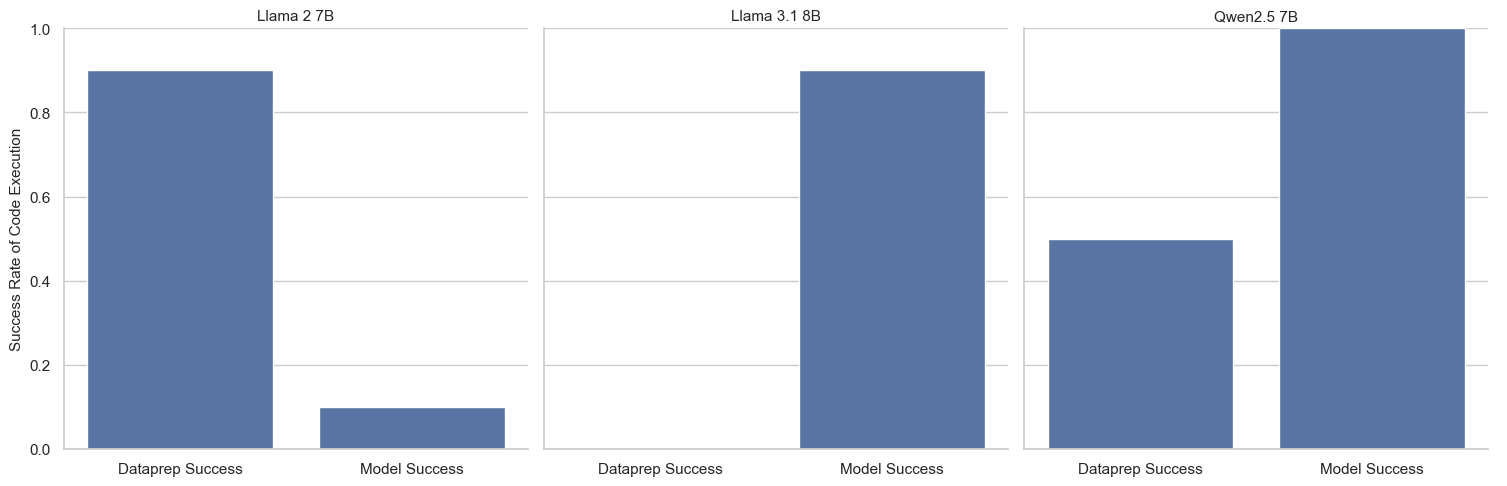

In [21]:
# Ensure success columns are numeric
df_original["Adaptive_dataprep_succes"] = pd.to_numeric(
    df_original["Adaptive_dataprep_succes"], errors="coerce"
)
df_original["Adaptive_model_code_succes"] = pd.to_numeric(
    df_original["Adaptive_model_code_succes"], errors="coerce"
)

# Compute mean success rates per backend
success_rates = (
    df_original
    .groupby("LLM_backend")[[
        "Adaptive_dataprep_succes",
        "Adaptive_model_code_succes"
    ]]
    .mean()
    .reset_index()
)

# Reshape to long format for seaborn
success_long = success_rates.melt(
    id_vars="LLM_backend",
    var_name="Task",
    value_name="Success_rate"
)

# Clean task names
success_long["Task"] = success_long["Task"].replace({
    "Adaptive_dataprep_succes": "Dataprep Success",
    "Adaptive_model_code_succes": "Model Success"
})

# Faceted bar plot
g = sns.catplot(
    data=success_long,
    x="Task",
    y="Success_rate",
    col="LLM_backend",
    kind="bar",
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("", "Success Rate of Code Execution")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))

plt.tight_layout()
plt.savefig("fig_code_execution_success.png", bbox_inches="tight")
plt.show()

### **6. Number of iterations per run, per LLM backend**

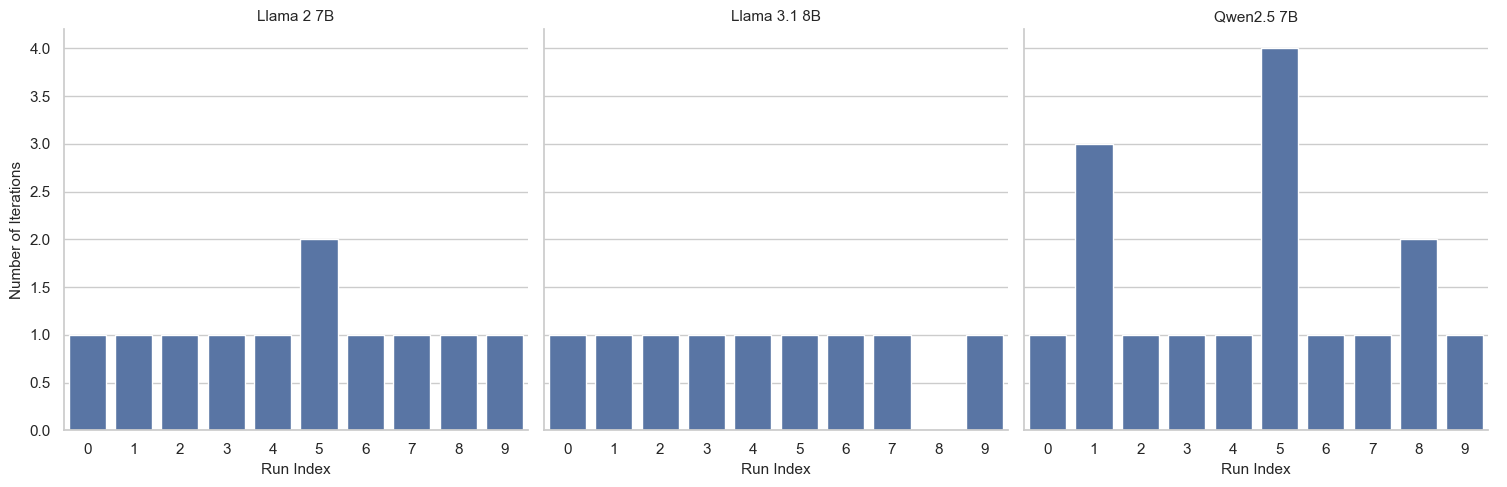

In [22]:
# Ensure numeric
df_original["Iterations"] = pd.to_numeric(
    df_original["Iterations"], errors="coerce"
)

# Create run index per backend (like your reset_index)
df_plot = (
    df_original
    .sort_values(["LLM_backend"])
    .copy()
)

df_plot["Run_Index"] = (
    df_plot.groupby("LLM_backend")
    .cumcount()
)

# Faceted bar plot
g = sns.catplot(
    data=df_plot,
    x="Run_Index",
    y="Iterations",
    col="LLM_backend",
    kind="bar",
    sharey=True
)

g.set_axis_labels("Run Index", "Number of Iterations")
g.set_titles("{col_name}")

plt.tight_layout()
plt.savefig("fig_iterations_per_backend.png", bbox_inches="tight")
plt.show()

### **7. BN uncertainty outcome**

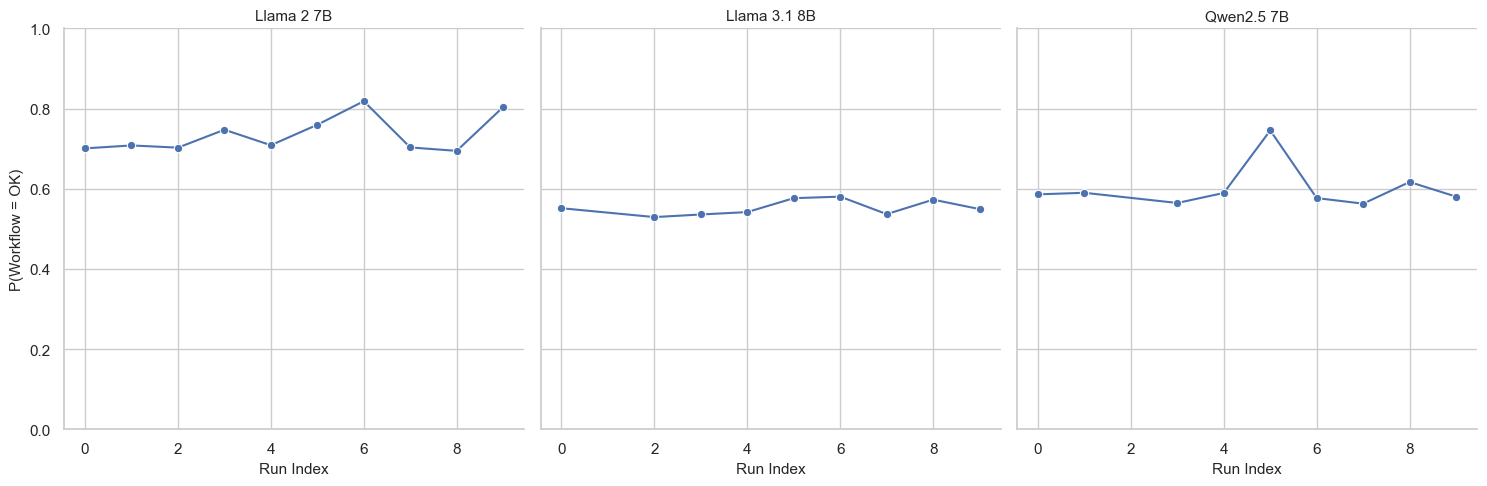

In [23]:
# Ensure numeric (handles NaN safely)
df_original["P(Workflow=OK)"] = pd.to_numeric(
    df_original["P(Workflow=OK)"], errors="coerce"
)

# Create run index per backend (like reset_index in your loop)
df_plot = df_original.copy()
df_plot["Run_Index"] = (
    df_plot
    .groupby("LLM_backend")
    .cumcount()
)

# Faceted line plot
g = sns.relplot(
    data=df_plot,
    x="Run_Index",
    y="P(Workflow=OK)",
    col="LLM_backend",
    kind="line",
    marker="o",
    col_wrap=len(df_plot["LLM_backend"].unique()),
    height=5,
    aspect=1,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Run Index", "P(Workflow = OK)")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))

plt.tight_layout()
plt.savefig("fig_uncertainty_per_backend.png", bbox_inches="tight")
plt.show()

## **Adaptability tests**

In [24]:
# Inspect columns
print(df_test.columns)
df_test.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'sparsity',
       'sparsity_numeric', 'row_change', 'column_change', 'missing_rate',
       'target_shift', 'population_shift', 'correlation_shift',
       'severity_score'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Decision_model_review,sparsity,sparsity_numeric,row_change,column_change,missing_rate,target_shift,population_shift,correlation_shift,severity_score
0,32,20260216_142602,Llama 2 7B,Test_T1,1,CONSULT_ACTUARY,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.094551,0.129366,0.000000,0.000000,0.008308,0.000000,5.750045e-07,0.001572,0.001573
1,33,20260216_181131,Llama 2 7B,Test_T2,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.127942,0.129366,0.000000,0.000000,0.041698,0.000000,4.705761e-06,0.003475,0.003480
2,34,20260216_190533,Llama 2 7B,Test_T3,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086243,0.129365,0.029498,0.000000,0.000000,0.000057,2.350667e-07,0.001652,0.001710
3,35,20260217_071348,Llama 2 7B,Test_T4,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086247,0.129370,0.147490,0.000000,0.000000,0.000812,1.689517e-06,0.004710,0.005523
4,36,20260223_133530,Llama 2 7B,Test_T5,1,APPROVE,1,1,GLM,0,...,APPROVE_WITH_NOTES,0.086342,0.135681,0.000000,0.083333,0.000000,0.000000,0.000000e+00,0.000000,0.000000


### **8. Mean RMSE of test runs**

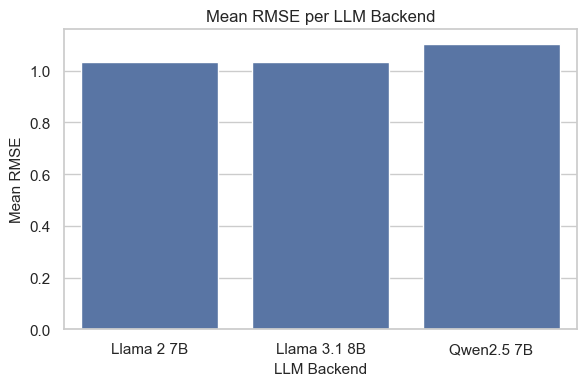

In [25]:
performance_summary = (
    df_test.groupby("LLM_backend")
      .agg({
          "RMSE": "mean",
          "MAE": "mean",
          "Poisson_deviance": "mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=performance_summary,
    x="LLM_backend",
    y="RMSE"
)

plt.title("Mean RMSE per LLM Backend")
plt.xlabel("LLM Backend")
plt.ylabel("Mean RMSE")
plt.tight_layout()
plt.savefig("fig_mean_rmse_per_backend_test.png", bbox_inches="tight")
plt.show()

### **9. Error detection versus test severity**

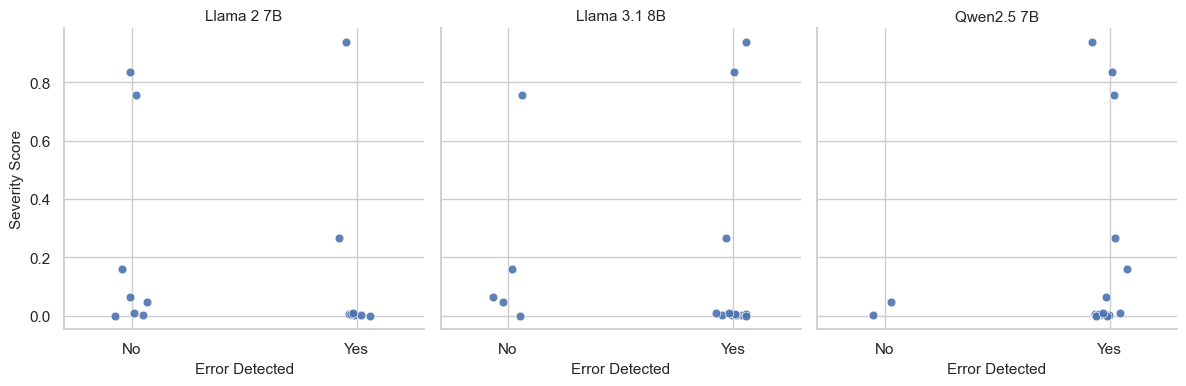

In [26]:
# For visualibility
df_test["Error_random"] = (
    df_test["Error_detected"] +
    np.random.uniform(-0.08, 0.08, size=len(df_test))
)

g = sns.FacetGrid(
    df_test,
    col="LLM_backend",
    col_order=df_test["LLM_backend"].unique(),
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Error_random",
    y="severity_score",
    alpha=0.9,
    s=40
)

g.set_axis_labels("Error Detected", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlim(-0.3, 1.3)

plt.tight_layout()
plt.savefig("fig_error_detected_severity_scatter.png", bbox_inches="tight")
plt.show()

### **10. Review decision when error was detected, versus test severity**

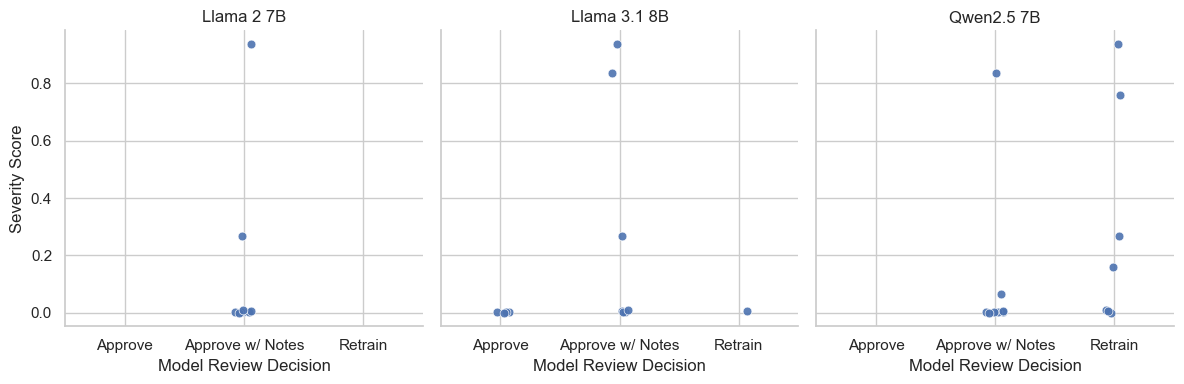

In [27]:
sns.set_theme(style="whitegrid")

# Filter to detected errors
df_detected = df_test[df_test["Error_detected"] == 1].copy()

# Ensure ordered categories (important!)
decision_order = [
    "APPROVE",
    "APPROVE_WITH_NOTES",
    "RETRAIN"
]

df_detected["Decision_model_review"] = pd.Categorical(
    df_detected["Decision_model_review"],
    categories=decision_order,
    ordered=True
)

# Add horizontal jitter
df_detected["Decision_numeric"] = df_detected["Decision_model_review"].cat.codes
df_detected["Decision_jitter"] = (
    df_detected["Decision_numeric"] +
    np.random.uniform(-0.08, 0.08, size=len(df_detected))
)

# Faceted scatter
g = sns.FacetGrid(
    df_detected,
    col="LLM_backend",
    col_order=df_test["LLM_backend"].unique(),
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Decision_jitter",
    y="severity_score",
    alpha=0.9,
    s=40
)

g.set_axis_labels("Model Review Decision", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([
        "Approve",
        "Approve w/ Notes",
        "Retrain"
    ])
    ax.set_xlim(-0.5, 2.5)

plt.tight_layout()
plt.savefig("fig_severity_model_review_scatter.png", bbox_inches="tight")
plt.show()

Optional: Model review decision conditional on error detection

<Figure size 700x500 with 0 Axes>

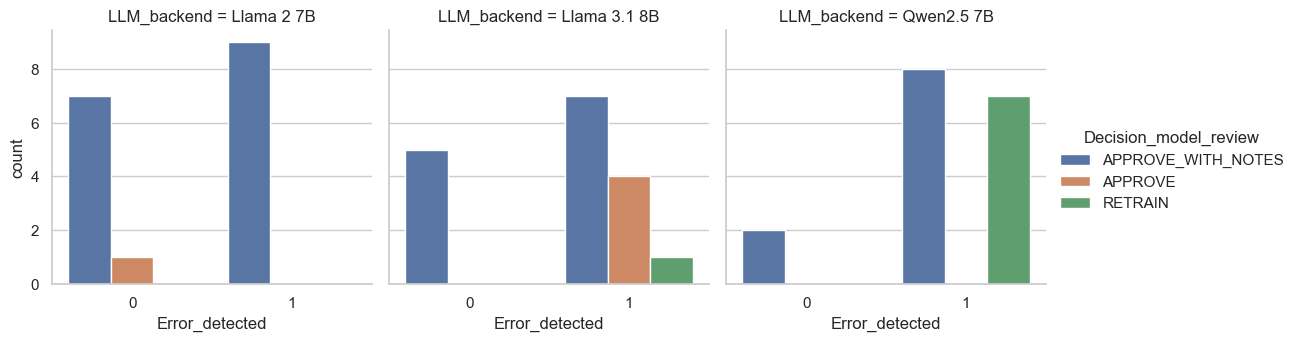

In [28]:
plt.figure(figsize=(7,5))

sns.catplot(
    data=df_test,
    x="Error_detected",
    hue="Decision_model_review",
    col="LLM_backend",
    kind="count",
    height=4,
    aspect=0.9
)

plt.subplots_adjust(top=0.8)
plt.savefig("fig_backend_error_modelreview.png", bbox_inches="tight")
plt.show()

### **11. Compare (un)certainty scores over test severity**

C:\Users\bart_\AppData\Local\Temp\ipykernel_28492\620159946.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["severity_bin", "LLM_backend"])


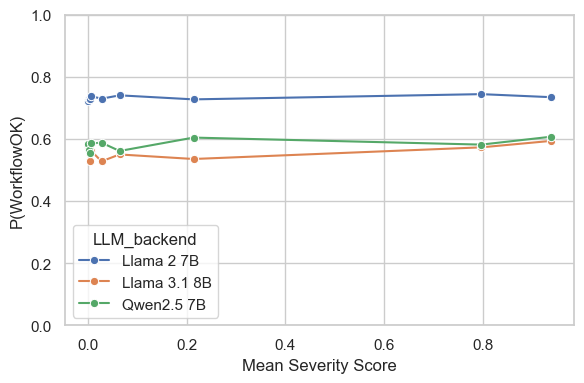

In [29]:
# Create severity deciles
df_test["severity_bin"] = pd.qcut(
    df_test["severity_score"],
    q=10,
    duplicates="drop"
)

summary = (
    df_test
    .groupby(["severity_bin", "LLM_backend"])
    .agg(
        mean_severity=("severity_score", "mean"),
        prob_workflowok=("P(Workflow=OK)", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=summary,
    x="mean_severity",
    y="prob_workflowok",
    hue="LLM_backend",
    marker="o"
)

plt.xlabel("Mean Severity Score")
plt.ylabel("P(WorkflowOK)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("fig_workflowok_probability_test.png", bbox_inches="tight")
plt.show()

### **12. Plot distributions of the explanation assessments and compare to Original runs (only for Qwen)**

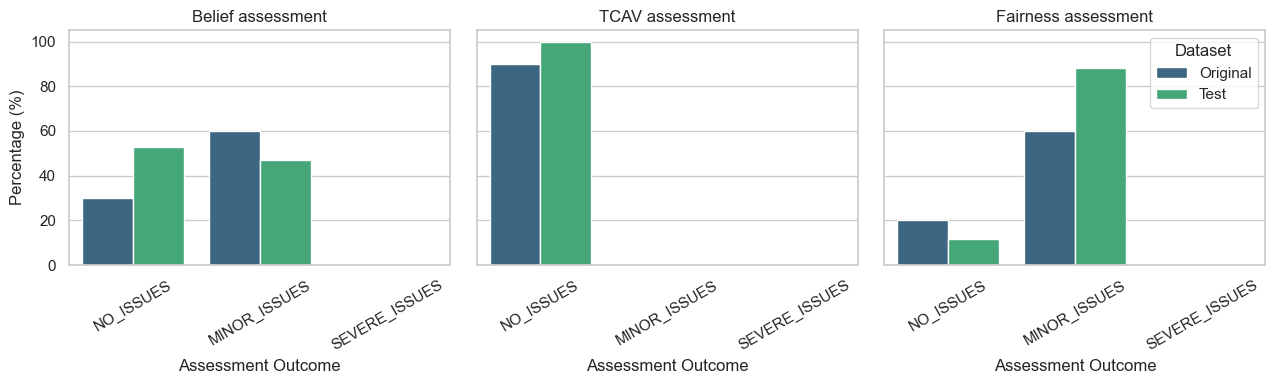

In [30]:
assessment_categories = ["NO_ISSUES", "MINOR_ISSUES", "SEVERE_ISSUES"]
assessment_cols = ["Belief_assessment", "TCAV_assessment", "Fairness_assessment"]

# Filter backend if needed
df_test_qwen = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"].copy()
df_original_qwen = df_original[df_original["LLM_backend"] == "Qwen2.5 7B"].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# Dataset sizes (for normalization)
n_test = len(df_test_qwen)
n_original = len(df_original_qwen)

for ax, col in zip(axes, assessment_cols):

    # Count distributions
    test_counts = (
        df_test_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    original_counts = (
        df_original_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    # Convert to percentages
    test_pct = 100 * test_counts / n_test if n_test > 0 else test_counts * 0
    original_pct = 100 * original_counts / n_original if n_original > 0 else original_counts * 0

    # Build plot dataframe (Original first, then Test)
    plot_df = pd.DataFrame({
        "Outcome": list(assessment_categories) * 2,
        "Dataset": ["Original"] * len(assessment_categories) +
                ["Test"] * len(assessment_categories),
        "Percentage": list(original_pct.values) + list(test_pct.values)
    })

    sns.barplot(
        data=plot_df,
        x="Outcome",
        y="Percentage",
        hue="Dataset",
        hue_order=["Original", "Test"],
        palette="viridis",
        ax=ax
    )

    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Assessment Outcome")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis='x', rotation=30)

    if ax != axes[-1]:
        ax.legend_.remove()

plt.tight_layout()

plt.savefig("fig_qwen_assessment_distributions.png", bbox_inches="tight")
plt.show()

### **13. Estimate which test characteristics had the most effect on triggering the error detection**

In [38]:
# Test dataset features to use
FEATURES = [
    "sparsity",
    "row_change",
    "column_change",
    "missing_rate",
    "target_shift",
    "population_shift",
    "correlation_shift"
]

TARGET = "Error_detected"

# Clean dataset copy
df_model = df_test.copy()

# Convert percentage-like columns if stored as strings
for col in FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Drop missing values
df_model = df_model.dropna(subset=FEATURES + [TARGET, "LLM_backend"])

# Container for results
importance_results = {}

# Train model per backend
for backend in df_model["LLM_backend"].unique():

    df_backend = df_model[df_model["LLM_backend"] == backend]

    if len(df_backend) < 10:
        continue  # avoid unstable models

    X = df_backend[FEATURES]
    y = df_backend[TARGET]

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Logistic regression (L2 regularized)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)

    # Feature importance = absolute standardized coefficient
    importance = pd.Series(
        np.abs(model.coef_[0]),
        index=FEATURES
    ).sort_values(ascending=False)

    importance_results[backend] = importance

# Convert to dataframe
importance_df = pd.DataFrame(importance_results)

print("\n=== Feature Importance by Backend ===")
print(importance_df)


=== Feature Importance by Backend ===
                   Llama 2 7B  Llama 3.1 8B  Qwen2.5 7B
column_change        0.068458      0.387244    0.240239
correlation_shift    0.902811      0.640238    0.284472
missing_rate         0.379901      0.402592    0.071397
population_shift     0.746746      0.905364    0.830039
row_change           0.601717      0.245080    0.005854
sparsity             0.130472      0.112435    0.133689
target_shift         0.555859      0.654373    0.204224


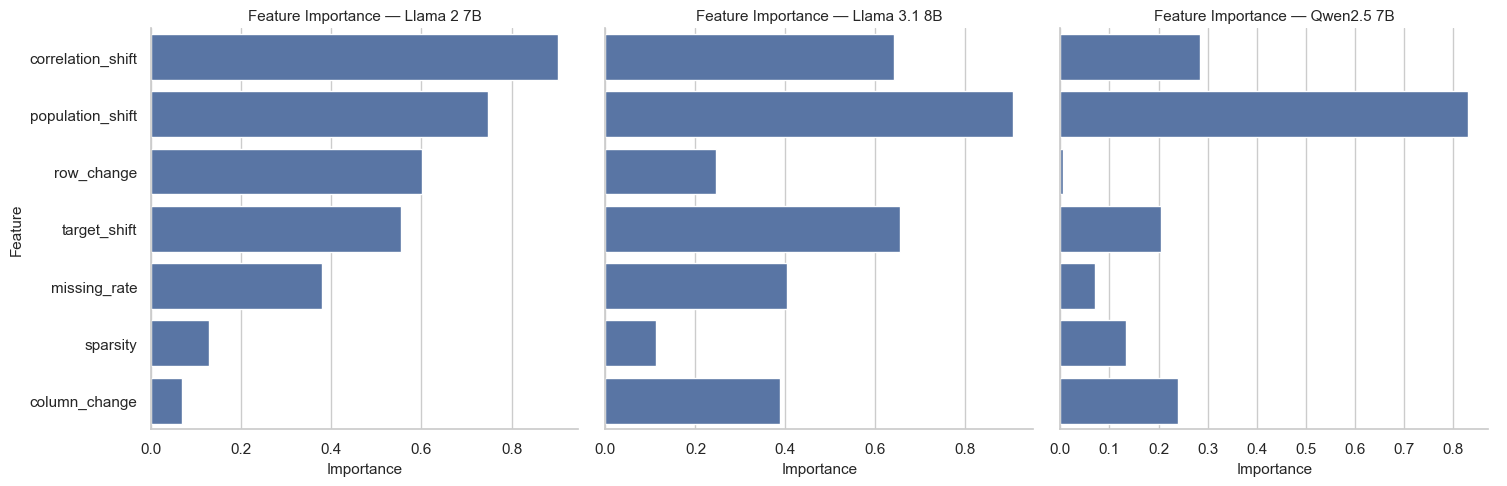

In [39]:
# Select up to 3 backends
backend_list = importance_df.columns[:3]

# Convert to long format
importance_long = (
    importance_df[backend_list]
    .abs()
    .reset_index()
    .melt(id_vars="index",
        var_name="LLM_backend",
        value_name="Importance")
    .rename(columns={"index": "Feature"})
)

# Sort features within each backend
importance_long = (
    importance_long
    .sort_values(["LLM_backend", "Importance"], ascending=[True, False])
)

# Faceted horizontal bar plot
g = sns.catplot(
    data=importance_long,
    y="Feature",
    x="Importance",
    col="LLM_backend",
    kind="bar",
    sharex=False,
    sharey=True,
    height=5,
    aspect=1
)

g.set_axis_labels("Importance", "Feature")
g.set_titles("Feature Importance — {col_name}")
g.fig.tight_layout()

plt.savefig("fig_feature_importance.png", bbox_inches="tight")
plt.show()

Beeswarm plot (only for Qwen model):

In [40]:
import shap

backend = backend_list[2]  # example: first backend
df_backend = df_model[df_model["LLM_backend"] == backend]

X = df_backend[FEATURES]
y = df_backend[TARGET]

scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=FEATURES,
    index=X.index
)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# SHAP explainer for linear model
explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_scaled)

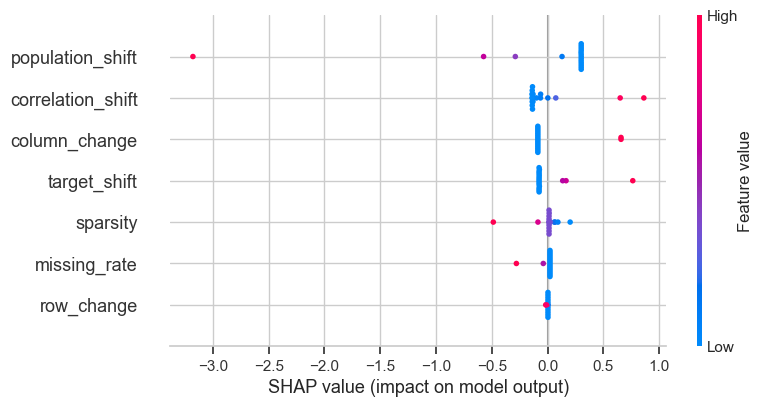

<Figure size 640x480 with 0 Axes>

In [45]:
shap.plots.beeswarm(shap_values, show=True)
plt.savefig("fig_shap_beeswarm.png", dpi=300, bbox_inches="tight")